# 03 — Definitive Evaluation

The single source of truth for the paper's quantitative numbers. Every model's raw
detections are de-duplicated with one **explicit, class-agnostic, confidence-ranked
radius NMS** (`config.point_nms`, **30 px**), then scored against ground truth by
**Hungarian matching** (**75 px**) at confidence 0.25. The 30 px suppression equals
the deployed POLO setting (DoR 0.3 × 100 px radius) and is applied uniformly, so POLO
and the localizer use the **same** near-detection definition (rather than POLO's
internal DoR-NMS, which depends on a data.yaml baked into the checkpoint).

**Options** (top of notebook): which `SPLIT` and which `CAMERA_FILTER`.
Deployment-matched defaults are **feeder + test** (and feeder + valid). Exit-cam
images are *train-only*, so evaluating on them is **not** held-out — flagged
explicitly below.

**Outputs**
1. Old localizer vs POLO
2. Model-size comparison (polo26n / s / m): F1, P/R, classification, params, speed
3. Deployed-model deep dive (polo26n): per-class, confusion, per-session,
   per-image error histogram, failure gallery

In [1]:
import sys
import inspect
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from ultralytics import YOLO

from mosaic.core.dataset import Dataset
import mosaic.tracking.pose_training as pose
from mosaic.tracking.pose_training.localizer_model import LocalizerEncoder

# Make the repo-root config.py importable regardless of the kernel's working dir
_REPO_ROOT = Path.cwd()
while not (_REPO_ROOT / 'config.py').exists() and _REPO_ROOT != _REPO_ROOT.parent:
    _REPO_ROOT = _REPO_ROOT.parent
sys.path.insert(0, str(_REPO_ROOT))
import config

## Configuration

In [2]:
# ── mosaic Dataset root ──
DATASET_BASE = Path('/Volumes/JD-SSD/feeder-detection-model/dataset')   # your working dataset
ds = Dataset(DATASET_BASE / 'dataset.yaml').load()

# Eval dataset dir: prefer feeder_only; fall back to cvat_converted if not built.
DATA_DIR = config.feeder_only_dir(ds)
if not (DATA_DIR / 'test' / 'images').exists():
    DATA_DIR = config.cvat_converted_dir(ds)
print('Eval dataset:', DATA_DIR)

# ── Which split + cameras ──
SPLIT = 'test'            # 'test' | 'valid' | 'train'
CAMERA_FILTER = 'feeder'  # 'feeder' (deployment) | 'exit' (TRAIN-only) | 'all'

# ── Trained weights: Johan's final runs, downloaded once into models/_pretrained/. ──
# These are the OUTPUTS of training (02_train_polo) — using them here skips re-fitting;
# re-running 02 with config.POLO_FINAL reproduces them. Any path that doesn't exist
# falls back to the REPORTED numbers below, so this cell runs before AND after download.
# polo26n may instead be the deployed export bb_hpc_dev/polo26_feedercams.pt.
W = ds.get_root('models') / '_pretrained'
MODELS = {
    'polo26n': W / 'polo26n.pt',
    'polo26s': W / 'polo26s.pt',
    'polo26m': W / 'polo26m.pt',
}
LOCALIZER_MODELS = {
    'localizer': W / 'localizer.pt',
}

# ── Johan's reported numbers (cross-check; feeder-only, same matching) ──
REPORTED = {
    'test':  {'polo26n': dict(f1=0.929, p=0.941, r=0.917, cls=0.999),
              'polo26s': dict(f1=0.932, p=0.942, r=0.922, cls=0.999),
              'polo26m': dict(f1=0.926, p=0.921, r=0.931, cls=0.998),
              'localizer': dict(f1=0.519, p=0.532, r=0.507, cls=0.838)},
    'valid': {'polo26n': dict(f1=0.990, p=0.990, r=0.990, cls=0.999),
              'polo26s': dict(f1=0.989, p=0.990, r=0.987, cls=1.000),
              'polo26m': dict(f1=0.983, p=0.981, r=0.985, cls=1.000),
              'localizer': dict(f1=0.531, p=0.507, r=0.557, cls=0.868)},
}

print('Settings: IMGSZ=%d  CONF=%.2f  DOR=%.2f  MATCH_RADIUS=%.0f px'
      % (config.IMGSZ, config.CONF, config.DOR, config.MATCH_RADIUS))
print('Device:', config.auto_device())

Eval dataset: /Volumes/JD-SSD/feeder-detection-model/dataset/models/polo/_polo_data/feeder_only
Settings: IMGSZ=640  CONF=0.25  DOR=0.00  MATCH_RADIUS=75 px
Device: mps


## Select images by split & camera

In [3]:
def gather_images(data_dir, split, camera_filter):
    img_dir = Path(data_dir) / split / 'images'
    paths = sorted(img_dir.glob('*.png'))
    if camera_filter != 'all':
        paths = [p for p in paths if config.camera_of(p.name) == camera_filter]
    return paths

image_paths = gather_images(DATA_DIR, SPLIT, CAMERA_FILTER)
label_dir = DATA_DIR / SPLIT / 'labels'
cam_counts = pd.Series([config.camera_of(p.name) for p in image_paths]).value_counts().to_dict()
print(f'{len(image_paths)} images   split={SPLIT}   camera={CAMERA_FILTER}   {cam_counts}')
if CAMERA_FILTER in ('exit', 'all') and SPLIT != 'train':
    print('CAVEAT: exit-cam images are TRAIN-only in the split; '
          'evaluating on them is NOT held-out.')

136 images   split=test   camera=feeder   {'feeder': 136}


## Evaluation methodology (shown for review)

In [4]:
print('Pipeline for every number below:')
print('  raw detections  ->  point_nms(%.0f px, class-agnostic)  ->  Hungarian match(%.0f px)\n'
      % (config.NMS_RADIUS, config.MATCH_RADIUS))
print(inspect.getsource(config.point_nms))
print(inspect.getsource(config.match))

Pipeline for every number below:
  raw detections  ->  point_nms(30 px, class-agnostic)  ->  Hungarian match(75 px)

def point_nms(points, radius: float = NMS_RADIUS, class_agnostic: bool = True):
    """Greedy, confidence-ranked radius suppression of point detections.

    ``points`` is a list of ``(x, y, class_id, conf)``.  Iterating from highest to
    lowest confidence, each kept detection suppresses all lower-confidence
    detections within ``radius`` pixels; returns the surviving tuples.  This is the
    single near-detection-suppression definition applied to every model in the eval
    (ported from the production ``point_nms`` in bb_pipeline).

    class_agnostic
        If True (default), suppress across all classes.  If False, only suppress
        detections sharing the same class.
    """
    if not points:
        return []
    xy = np.array([(p[0], p[1]) for p in points], dtype=float)
    conf = np.array([p[3] for p in points], dtype=float)
    cls = [p[2] for p in points

## Run evaluation for all configured models

In [5]:
def eval_polo(weights):
    model = YOLO(str(weights), task='locate')
    return config.run_point_eval(image_paths, label_dir, lambda p, im: config.polo_predict(model, p))

def eval_localizer(weights):
    model = LocalizerEncoder(num_classes=config.NUM_CLASSES,
                             initial_channels=config.INITIAL_CHANNELS)
    pose.load_localizer_weights(model, str(weights))
    model.eval()
    return config.run_point_eval(image_paths, label_dir, lambda p, im: config.localizer_predict(model, im))

results = {}
for name, w in {**MODELS, **LOCALIZER_MODELS}.items():
    if w is None or not Path(w).exists():
        print(f'skip {name}: no weights -> will use reported numbers')
        continue
    print(f'evaluating {name} ...')
    results[name] = eval_localizer(w) if name in LOCALIZER_MODELS else eval_polo(w)
print('recomputed:', list(results))

evaluating polo26n ...
WARNING ⚠️ WARNING ⚠️ dataset config not found for locate predictor; falling back to model radii. ('/home/beesbook/feeder_detection_model/dataset/models/polo-yolo11/_polo_data/cvat_converted/data.yaml' does not exist)
evaluating polo26s ...
WARNING ⚠️ WARNING ⚠️ dataset config not found for locate predictor; falling back to model radii. ('/home/johan/feeder-model-training/data/feeder_only/data.yaml' does not exist)
evaluating polo26m ...
WARNING ⚠️ WARNING ⚠️ dataset config not found for locate predictor; falling back to model radii. ('/home/johan/feeder-model-training/data/feeder_only/data.yaml' does not exist)
evaluating localizer ...
recomputed: ['polo26n', 'polo26s', 'polo26m', 'localizer']


In [6]:
def row_for(name):
    if name in results:
        r = results[name]
        return dict(model=name, F1=round(r.f1, 4), P=round(r.precision, 4),
                    R=round(r.recall, 4), ClassAcc=round(r.classification_accuracy, 4),
                    source='recomputed')
    rep = REPORTED.get(SPLIT, {}).get(name)
    if rep:
        return dict(model=name, F1=rep['f1'], P=rep['p'], R=rep['r'],
                    ClassAcc=rep['cls'], source='reported')
    return None

## Output 1 — Old localizer vs POLO

In [7]:
old_vs_polo = pd.DataFrame([r for r in (row_for('localizer'), row_for('polo26n')) if r])
display(old_vs_polo)

,model,F1,P,R,ClassAcc,source
0,localizer,0.5202,0.5358,0.5054,0.843,recomputed
1,polo26n,0.9241,0.8909,0.9598,0.999,recomputed


## Output 2 — Model-size comparison (polo26n / s / m)

In [8]:
def polo_stats(weights):
    m = YOLO(str(weights), task='locate')
    n_params = sum(p.numel() for p in m.model.parameters())
    subset = image_paths[:60]
    for p in subset[:10]:
        config.polo_predict(m, p)
    t = []
    for p in subset[10:60]:
        t0 = time.perf_counter()
        config.polo_predict(m, p)
        t.append(time.perf_counter() - t0)
    ms = float(np.mean(t)) * 1000 if t else float('nan')
    return n_params, ms, Path(weights).stat().st_size / 1e6

size_rows = []
for name in ('polo26n', 'polo26s', 'polo26m'):
    base = row_for(name)
    if base is None:
        continue
    w = MODELS.get(name)
    if name in results and w and Path(w).exists():
        n_params, ms, size_mb = polo_stats(w)
        base.update(params=f'{n_params/1e6:.1f}M', ms_per_img=round(ms, 1),
                    weight_MB=round(size_mb, 1))
    size_rows.append(base)

size_df = pd.DataFrame(size_rows)
print(f'Device={config.auto_device()} — record this GPU when citing ms/img.')
display(size_df)

WARNING ⚠️ WARNING ⚠️ dataset config not found for locate predictor; falling back to model radii. ('/home/beesbook/feeder_detection_model/dataset/models/polo-yolo11/_polo_data/cvat_converted/data.yaml' does not exist)
WARNING ⚠️ WARNING ⚠️ dataset config not found for locate predictor; falling back to model radii. ('/home/johan/feeder-model-training/data/feeder_only/data.yaml' does not exist)
WARNING ⚠️ WARNING ⚠️ dataset config not found for locate predictor; falling back to model radii. ('/home/johan/feeder-model-training/data/feeder_only/data.yaml' does not exist)
Device=mps — record this GPU when citing ms/img.


,model,F1,P,R,ClassAcc,source,params,ms_per_img,weight_MB
0,polo26n,0.9241,0.8909,0.9598,0.9990,recomputed,3.0M,46.2,6.2
1,polo26s,0.9266,0.9079,0.9461,0.9979,recomputed,11.1M,68.8,67.3
2,polo26m,0.9256,0.8971,0.9559,0.9990,recomputed,24.5M,95.5,148.0


## Output 3 — Deployed-model deep dive (polo26n)

In [9]:
DEEP = 'polo26n'
res = results.get(DEEP)
if res is None:
    print(f'No recomputed result for {DEEP}; point MODELS["{DEEP}"] at its weights.')
else:
    rows = []
    for c in range(config.NUM_CLASSES):
        if res.gt_class_counts[c] == 0:
            continue
        det = int(res.detected_class_counts[c])
        cor = int(res.correct_class_counts[c])
        rows.append(dict(cls=config.CLASS_NAMES[c],
                         annotated=int(res.gt_class_counts[c]),
                         detected=det, correct=cor,
                         accuracy=round(cor / det, 4) if det else 0.0))
    print('Detection: P=%.4f  R=%.4f  F1=%.4f   Classification=%.4f   (TP=%d FP=%d FN=%d)'
          % (res.precision, res.recall, res.f1, res.classification_accuracy,
             res.tp, res.fp, res.fn))
    display(pd.DataFrame(rows))

Detection: P=0.8909  R=0.9598  F1=0.9241   Classification=0.9990   (TP=980 FP=120 FN=41)


,cls,annotated,detected,correct,accuracy
0,UnmarkedBee,992,952,952,1.0000
1,MarkedBee,29,28,27,0.9643


In [10]:
# Confusion matrix (rows = ground-truth class, cols = predicted class)
if res is not None:
    conf = pd.DataFrame(res.confusion,
                        index=[f'gt:{n}' for n in config.CLASS_NAMES],
                        columns=[f'pred:{n}' for n in config.CLASS_NAMES])
    display(conf)

,pred:UnmarkedBee,pred:MarkedBee,pred:BeeInCell,pred:UpsideDownBee
gt:UnmarkedBee,952,0,0,0
gt:MarkedBee,1,27,0,0
gt:BeeInCell,0,0,0,0
gt:UpsideDownBee,0,0,0,0


In [11]:
# Per-session error breakdown (surfaces hard sessions, e.g. crowded/poor light)
if res is not None:
    per_img = pd.DataFrame(res.per_image)
    sess = (per_img.groupby('session')
            .agg(images=('name', 'size'), tp=('tp', 'sum'),
                 fp=('fp', 'sum'), fn=('fn', 'sum'), errors=('errors', 'sum'))
            .sort_values('errors', ascending=False))
    display(sess.head(15))

,images,tp,fp,fn,errors
session,,,,,
feedercamC_2025_07_09_14_47_59,20,248,79,29,108
feedercamD_2025_06_22_16_39_10,20,205,16,1,17
feedercamC_2025_07_02_12_37_40,10,108,8,6,14
feedercamD_2025_07_04_13_07_20,20,149,11,0,11
feedercamC_2025_06_25_07_26_05,10,87,1,5,6
feedercamB_2025_07_11_12_43_15,10,18,3,0,3
feedercamB_2025_07_09_09_22_59,20,135,2,0,2
feedercamA_2025_07_02_12_35_48,9,13,0,0,0
feedercamC_2025_07_04_20_09_16,17,17,0,0,0


   0 errors:   78  (57%)
   1 errors:   27  (20%)
  2+ errors:   31  (23%)


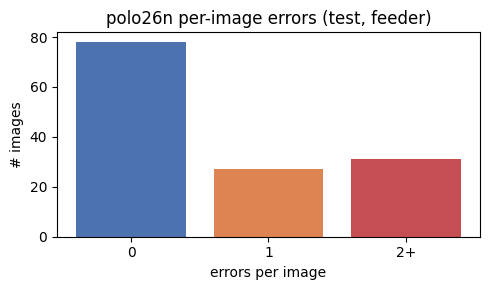

In [12]:
# Per-image error histogram (0 / 1 / 2+ errors)
if res is not None:
    cat = per_img['errors'].apply(lambda e: '0' if e == 0 else ('1' if e == 1 else '2+'))
    bins = cat.value_counts().reindex(['0', '1', '2+']).fillna(0).astype(int)
    n = int(bins.sum())
    for k in ['0', '1', '2+']:
        print(f'  {k:>2} errors: {bins[k]:4d}  ({bins[k]/n*100:.0f}%)')
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(bins.index, bins.values, color=['#4c72b0', '#dd8452', '#c44e52'])
    ax.set_xlabel('errors per image')
    ax.set_ylabel('# images')
    ax.set_title(f'{DEEP} per-image errors ({SPLIT}, {CAMERA_FILTER})')
    plt.tight_layout()
    plt.show()

WARNING ⚠️ WARNING ⚠️ dataset config not found for locate predictor; falling back to model radii. ('/home/beesbook/feeder_detection_model/dataset/models/polo-yolo11/_polo_data/cvat_converted/data.yaml' does not exist)


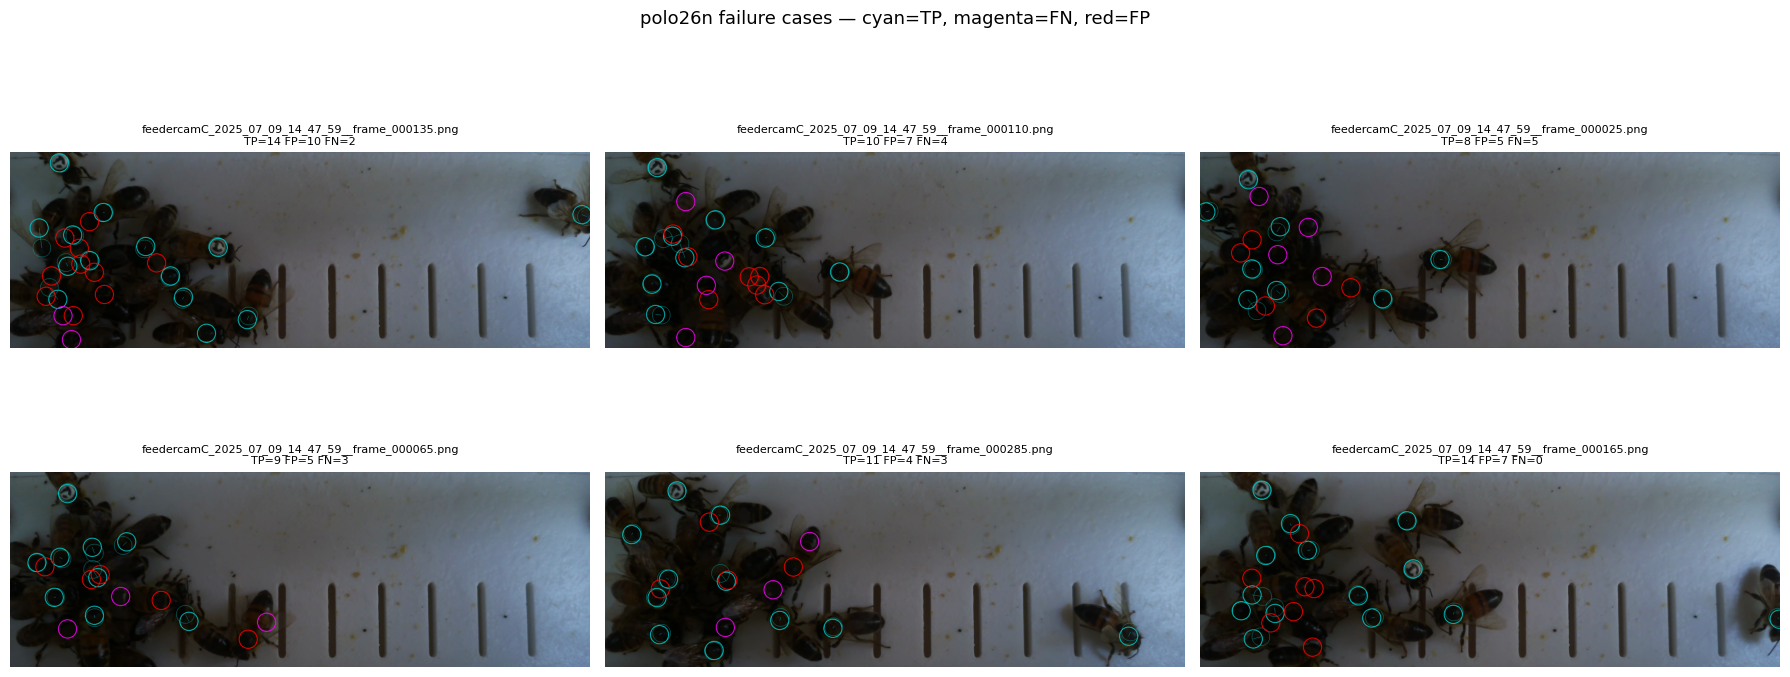

In [13]:
# Failure-case gallery: worst images, cyan=TP magenta=FN red=FP
def draw_overlay(img, gt, pred, mg, mp, ug, up, R=30):
    o = img.copy()
    for gi, pi in zip(mg, mp):
        gx, gy = int(gt[gi][0]), int(gt[gi][1])
        px, py = int(pred[pi][0]), int(pred[pi][1])
        cv2.circle(o, (gx, gy), R, (200, 200, 0), 2)
        cv2.circle(o, (px, py), R, (200, 200, 0), 1)
        cv2.line(o, (gx, gy), (px, py), (200, 200, 0), 1)
    for gi in ug:
        cv2.circle(o, (int(gt[gi][0]), int(gt[gi][1])), R, (255, 0, 255), 2)
    for pi in up:
        cv2.circle(o, (int(pred[pi][0]), int(pred[pi][1])), R, (0, 0, 255), 2)
    return o

if res is not None and MODELS.get(DEEP) and Path(MODELS[DEEP]).exists():
    worst = per_img.sort_values('errors', ascending=False).head(6)
    model = YOLO(str(MODELS[DEEP]), task='locate')
    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    axes = axes.ravel()
    for ax, (_, row) in zip(axes, worst.iterrows()):
        fp = DATA_DIR / SPLIT / 'images' / row['name']
        img = cv2.imread(str(fp))
        h, w = img.shape[:2]
        gt = config.load_gt(label_dir / (fp.stem + '.txt'), w, h)
        pred = config.polo_predict(model, fp)
        mg, mp, ug, up = config.match(gt, pred)
        o = draw_overlay(img, gt, pred, mg, mp, ug, up)
        ax.imshow(cv2.cvtColor(o, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{row['name']}\nTP={row['tp']} FP={row['fp']} FN={row['fn']}", fontsize=8)
        ax.axis('off')
    for ax in axes[len(worst):]:
        ax.axis('off')
    fig.suptitle(f'{DEEP} failure cases — cyan=TP, magenta=FN, red=FP', fontsize=13)
    plt.tight_layout()
    plt.show()

## Export numbers for the paper

In [14]:
summary = []
for name in list(MODELS) + list(LOCALIZER_MODELS):
    r = row_for(name)
    if r:
        summary.append({**r, 'split': SPLIT, 'camera': CAMERA_FILTER})
summary_df = pd.DataFrame(summary)
out_path = Path('eval_results.csv')
summary_df.to_csv(out_path, index=False)
print('wrote', out_path.resolve())
display(summary_df)

wrote /Users/jacob/Documents/GitHub/BioroboticsLab/feeder-model-training/notebooks/eval_results.csv


,model,F1,P,R,ClassAcc,source,split,camera
0,polo26n,0.9241,0.8909,0.9598,0.9990,recomputed,test,feeder
1,polo26s,0.9266,0.9079,0.9461,0.9979,recomputed,test,feeder
2,polo26m,0.9256,0.8971,0.9559,0.9990,recomputed,test,feeder
3,localizer,0.5202,0.5358,0.5054,0.8430,recomputed,test,feeder


In [15]:
# Sensitivity: how much does the one hard session move the number? (report both, honestly)
EXCLUDE = ['feedercamC_2025_07_09_14_47_59']   # low-light, dense, GT flagged unreliable
per_img = pd.DataFrame(results['polo26n'].per_image)
for label, sub in [('all test sessions', per_img),
                   (f'excluding {len(EXCLUDE)} hard session(s)', per_img[~per_img.session.isin(EXCLUDE)])]:
    tp, fp, fn = int(sub.tp.sum()), int(sub.fp.sum()), int(sub.fn.sum())
    p = tp/(tp+fp) if tp+fp else 0; r = tp/(tp+fn) if tp+fn else 0
    f1 = 2*p*r/(p+r) if p+r else 0
    print(f'{label:34s}: F1={f1:.4f}  P={p:.4f}  R={r:.4f}   ({len(sub)} imgs, TP={tp} FP={fp} FN={fn})')


all test sessions                 : F1=0.9241  P=0.8909  R=0.9598   (136 imgs, TP=980 FP=120 FN=41)
excluding 1 hard session(s)       : F1=0.9651  P=0.9470  R=0.9839   (116 imgs, TP=732 FP=41 FN=12)
